### AUROC(Area Under Receiver Operating Characteristics)
- F1값은 정책과 임계값에 따라 달라짐
- 변화하는 임계값에 따른 모델의 성능 -> 모델의 강인함(robustness)
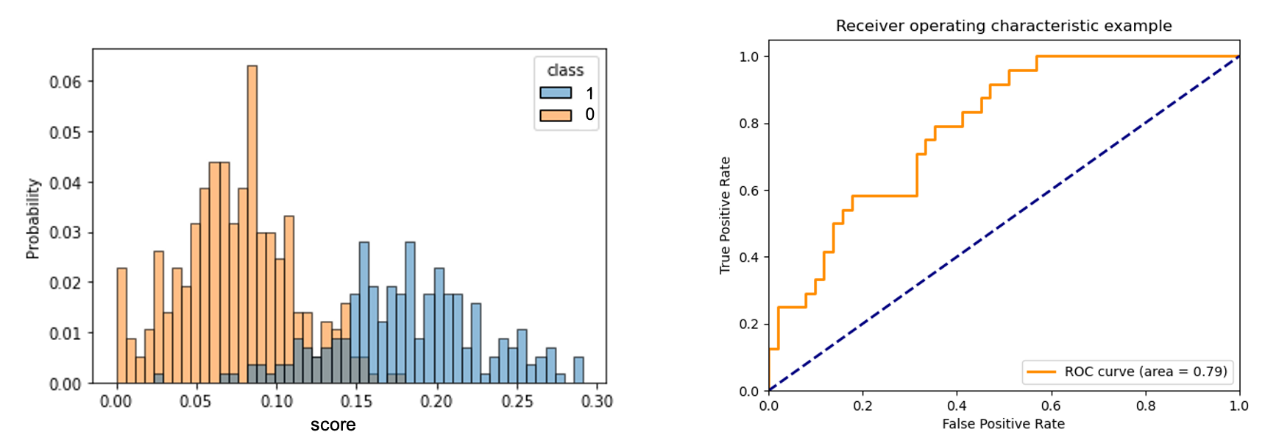
- 두 클래스가 겹치는 구간이 적을수록 모델 정확도가 유리함
- 왼쪽 그림에서 임계값을 변경하면 confusion matrix가 달라짐
- 임계값을 바꿔가며 TPR(y축)과 FPR(x축)의 변화를 기록하면 오른쪽 그림이 됨
  - TPR(True Positive Rate), FPR
  - TPR = $\displaystyle \frac{TP}{TP+FN}$ FPR = $\displaystyle \frac{FP}{FP+FN}$
- 그래프의 아래쪽 면적(AUROC)이 클수록 모델이 좋은 성능을 가짐

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['class'] = cancer.target


data = torch.from_numpy(df.values).float()

x = data[:, :-1]
y = data[:, -1:]

print(x.shape, y.shape)

ratio = [.6, .2, .2]
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt
cnts = [train_cnt, valid_cnt, test_cnt]

print("Train %d / Valid %d / Test %d samples." %(train_cnt, valid_cnt, test_cnt))

torch.Size([569, 30]) torch.Size([569, 1])
Train 341 / Valid 113 / Test 115 samples.


In [2]:
indices= torch.randperm(data.size(0))
x=torch.index_select(x, dim=0, index=indices)
y=torch.index_select(y, dim=0, index=indices)

x=list(x.split(cnts, dim=0))
y=y.split(cnts, dim=0)

for x_i, y_i in zip(x,y):
    print(x_i.size(),y_i.size())

torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])


In [3]:
scaler = StandardScaler()
scaler.fit(x[0].numpy())

x[0] = torch.from_numpy(scaler.transform(x[0].numpy())).float()
x[1] = torch.from_numpy(scaler.transform(x[1].numpy())).float()
x[2] = torch.from_numpy(scaler.transform(x[2].numpy())).float()

In [4]:
n_epochs = 1000
batch_size = 32
print_interval = 10
early_stop = 100

In [5]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25),
    nn.LeakyReLU(),
    nn.Linear(25, 20),
    nn.LeakyReLU(),
    nn.Linear(20, 15),
    nn.LeakyReLU(),
    nn.Linear(15, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 5),
    nn.LeakyReLU(),
    nn.Linear(5, y[0].size(-1)),
    nn.Sigmoid()
)

optimizer = optim.Adam(model.parameters())

In [6]:
from copy import deepcopy

lowest_loss = np.inf
best_model = None
lowest_epoch = np.inf

In [7]:
import time

train_history, valid_history = [], []

start = time.time()

for i in range(n_epochs):
    # Shuffle
    indices = torch.randperm(x[0].size(0))
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0

    for x_i, y_i in zip(x_, y_): # iteraction: 12,384 // 256 + 1 = 49
        y_hat_i = model(x_i)
        loss = F.mse_loss(y_hat_i, y_i)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()        
        train_loss += float(loss)
        
    train_loss = train_loss / len(x_) # 1 에폭당 평균 손실값

    with torch.no_grad(): # 계산 그래프 생성을 하지 않음
        #  shuffle 과정 필요 없음
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)

        valid_loss = 0

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = F.mse_loss(y_hat_i, y_i)

            valid_loss += loss
    valid_loss = valid_loss/ len(x_) # 1 epoch 당 평균 손실값

    # 손실곡선을 그리기 위한 손실값 저장
    train_history += [train_loss] # epoch 마다 학습 손실값 차례로 저장
    valid_history += [valid_loss] # epoch 마다 검증 손길값 차례로 저장

    # 출력
    if (i+1) % print_interval == 0:
        print('Epoch %d/%d: train loss = %.4e          valid_loss=%.4e          lowest_loss=%.4e' % (
            i+1,n_epochs, train_loss, valid_loss, lowest_loss))
        start = time.time()
    # 검증 손실의 최소값 찾기
    if valid_loss<=lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i+1:
            print("There is no improvement during last %d epochs." % early_stop)
            break
print("The best validation loss from epoch %d: %.4e" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model)

C:\Users\legna\AppData\Local\Temp\ipykernel_14056\735732500.py:25: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  train_loss += float(loss)


Epoch 10/1000: train loss = 9.9545e-02          valid_loss=8.0568e-02          lowest_loss=1.0732e-01
Epoch 20/1000: train loss = 5.5247e-03          valid_loss=3.7716e-02          lowest_loss=3.3762e-02
Epoch 30/1000: train loss = 3.4199e-03          valid_loss=4.1296e-02          lowest_loss=3.3762e-02
Epoch 40/1000: train loss = 3.0564e-03          valid_loss=4.2733e-02          lowest_loss=3.3762e-02
Epoch 50/1000: train loss = 2.9393e-03          valid_loss=4.3410e-02          lowest_loss=3.3762e-02
Epoch 60/1000: train loss = 2.9049e-03          valid_loss=4.3876e-02          lowest_loss=3.3762e-02
Epoch 70/1000: train loss = 2.8811e-03          valid_loss=4.4175e-02          lowest_loss=3.3762e-02
Epoch 80/1000: train loss = 2.8655e-03          valid_loss=4.4432e-02          lowest_loss=3.3762e-02
Epoch 90/1000: train loss = 2.8580e-03          valid_loss=4.4591e-02          lowest_loss=3.3762e-02
Epoch 100/1000: train loss = 2.8535e-03          valid_loss=4.4754e-02          lo

<All keys matched successfully>

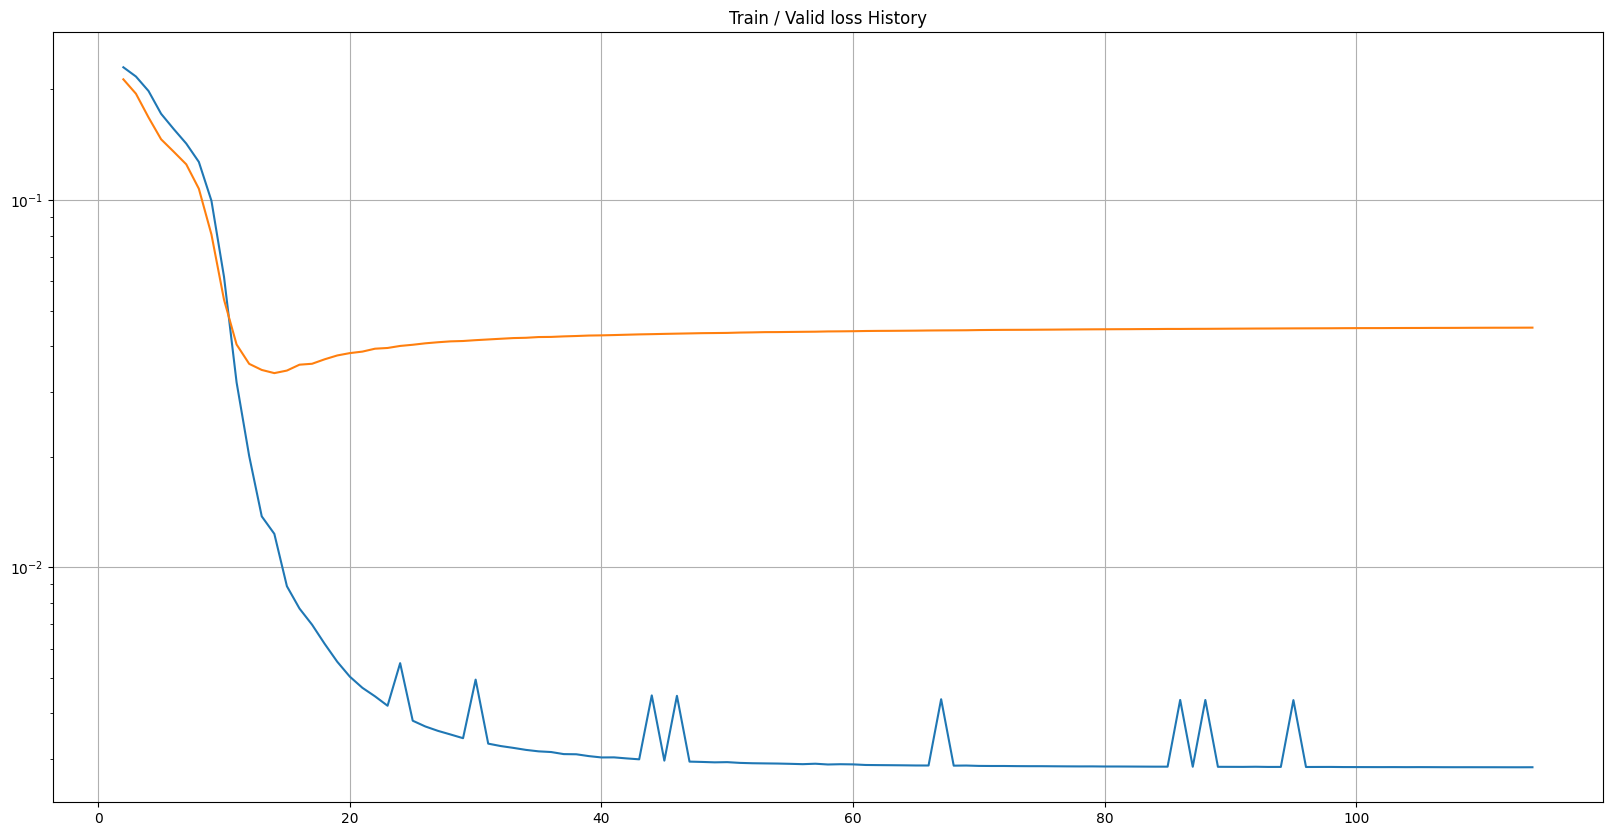

In [8]:
plot_from = 2

plt.figure(figsize=(20,10))
plt.grid(True)
plt.title("Train / Valid loss History")
plt.plot(range(plot_from, len(train_history)), train_history[plot_from:], label='Train_loss')
plt.plot(range(plot_from, len(valid_history)), valid_history[plot_from:], label='Valid_loss')
plt.yscale('log')
plt.show()

torch.Size([569, 30]) torch.Size([569, 1])
Train 341 / Valid 113 / Test 115 samples.
torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])
Epoch 10/10000: train loss = 1.5212e-01          valid_loss=1.2926e-01          lowest_loss=1.7942e-01
Epoch 20/10000: train loss = 1.0966e-02          valid_loss=3.3942e-02          lowest_loss=2.1313e-02
Epoch 30/10000: train loss = 8.3303e-03          valid_loss=4.0096e-02          lowest_loss=2.1313e-02
Epoch 40/10000: train loss = 7.7985e-03          valid_loss=4.1748e-02          lowest_loss=2.1313e-02
Epoch 50/10000: train loss = 7.5205e-03          valid_loss=4.7249e-02          lowest_loss=2.1313e-02
Epoch 60/10000: train loss = 5.8045e-03          valid_loss=4.7678e-02          lowest_loss=2.1313e-02
Epoch 70/10000: train loss = 5.7218e-03          valid_loss=4.7702e-02          lowest_loss=2.1313e-02
Epoch 80/10000: train loss = 5.6884e-03          valid_loss=4.770

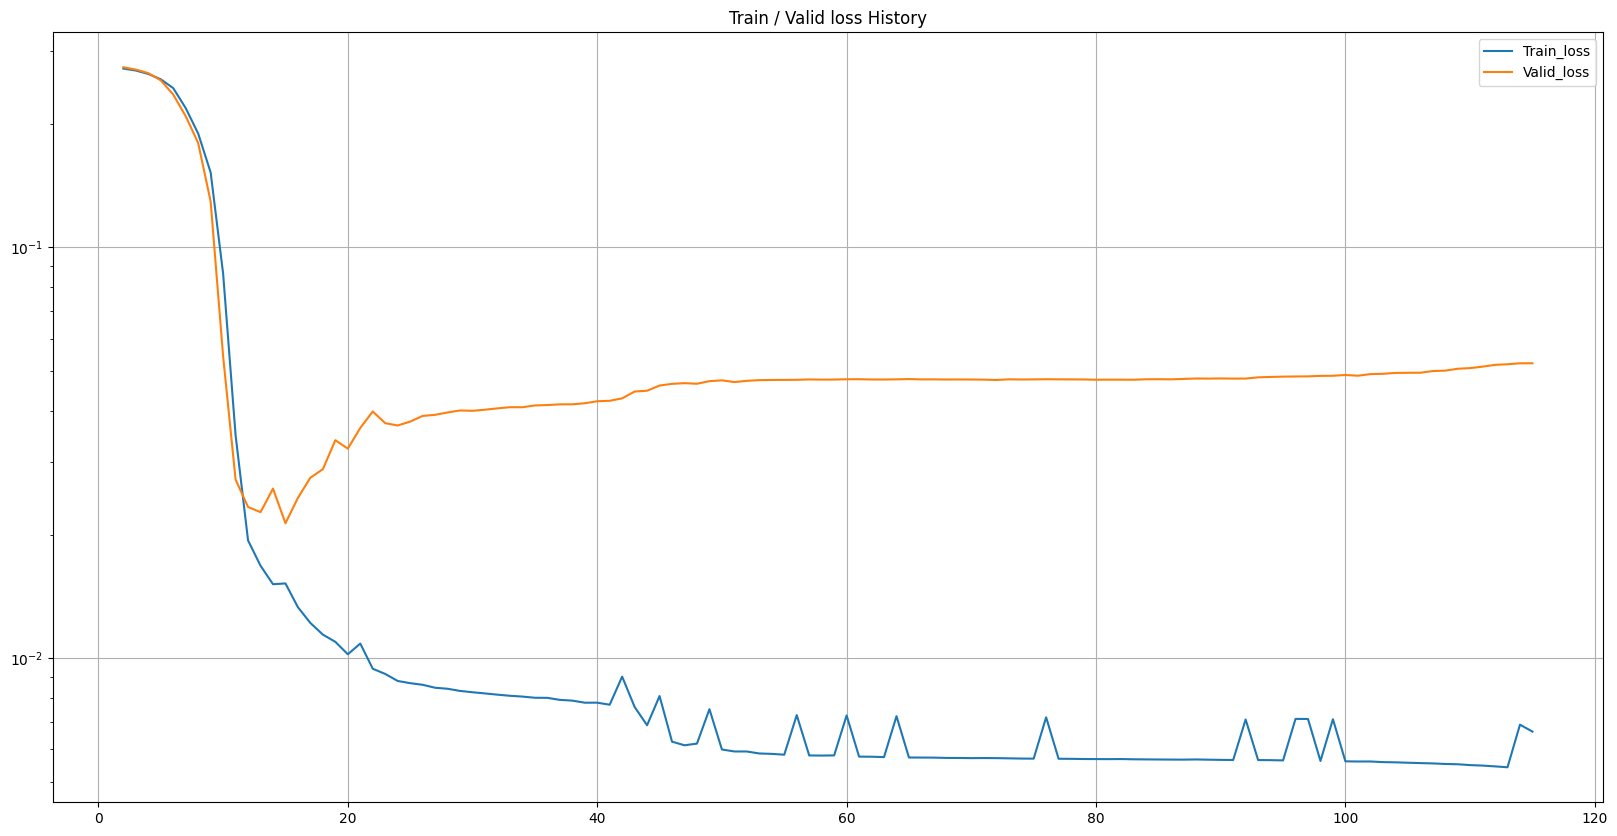

In [23]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['class'] = cancer.target


data = torch.from_numpy(df.values).float()

x = data[:, :-1]
y = data[:, -1:]

print(x.shape, y.shape)

ratio = [.6, .2, .2]
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt
cnts = [train_cnt, valid_cnt, test_cnt]

print("Train %d / Valid %d / Test %d samples." %(train_cnt, valid_cnt, test_cnt))

indices= torch.randperm(data.size(0))
x=torch.index_select(x, dim=0, index=indices)
y=torch.index_select(y, dim=0, index=indices)

x=list(x.split(cnts, dim=0))
y=y.split(cnts, dim=0)

for x_i, y_i in zip(x,y):
    print(x_i.size(),y_i.size())

scaler = StandardScaler()
scaler.fit(x[0].numpy())

x[0] = torch.from_numpy(scaler.transform(x[0].numpy())).float()
x[1] = torch.from_numpy(scaler.transform(x[1].numpy())).float()
x[2] = torch.from_numpy(scaler.transform(x[2].numpy())).float()

n_epochs = 10000
batch_size = 32
print_interval = 10
early_stop = 100

model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25),
    nn.LeakyReLU(),
    nn.Linear(25, 20),
    nn.LeakyReLU(),
    nn.Linear(20, 15),
    nn.LeakyReLU(),
    nn.Linear(15, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 5),
    nn.LeakyReLU(),
    nn.Linear(5, y[0].size(-1)),
    nn.Sigmoid()
)

optimizer = optim.Adam(model.parameters())

from copy import deepcopy

lowest_loss = np.inf
best_model = None
lowest_epoch = np.inf

import time

train_history, valid_history = [], []

start = time.time()

for i in range(n_epochs):
    # Shuffle
    indices = torch.randperm(x[0].size(0))
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0

    for x_i, y_i in zip(x_, y_): # iteraction: 12,384 // 256 + 1 = 49
        y_hat_i = model(x_i)
        loss = F.mse_loss(y_hat_i, y_i)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()        
        train_loss += float(loss)
        
    train_loss = train_loss / len(x_) # 1 에폭당 평균 손실값

    with torch.no_grad(): # 계산 그래프 생성을 하지 않음
        #  shuffle 과정 필요 없음
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)

        valid_loss = 0

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = F.mse_loss(y_hat_i, y_i)

            valid_loss += loss
    valid_loss = valid_loss/ len(x_) # 1 epoch 당 평균 손실값

    # 손실곡선을 그리기 위한 손실값 저장
    train_history += [train_loss] # epoch 마다 학습 손실값 차례로 저장
    valid_history += [valid_loss] # epoch 마다 검증 손길값 차례로 저장

    # 출력
    if (i+1) % print_interval == 0:
        print('Epoch %d/%d: train loss = %.4e          valid_loss=%.4e          lowest_loss=%.4e' % (
            i+1,n_epochs, train_loss, valid_loss, lowest_loss))
        start = time.time()
    # 검증 손실의 최소값 찾기
    if valid_loss<=lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i+1:
            print("There is no improvement during last %d epochs." % early_stop)
            break
print("The best validation loss from epoch %d: %.4e" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model)

plot_from = 2

plt.figure(figsize=(20,10))
plt.grid(True)
plt.title("Train / Valid loss History")
plt.plot(range(plot_from, len(train_history)), train_history[plot_from:], label='Train_loss')
plt.plot(range(plot_from, len(valid_history)), valid_history[plot_from:], label='Valid_loss')
plt.yscale('log')
plt.legend()
plt.show()

### 다중 클래스 분류
- 원 핫 벡터- -> 정답은 클래스 중 한 곳만 1을 주고 나머지는 0을 부여
- 각 클래스 별 확률값을 구함

### 일반 분류 문제 해결을 위한 심층심경망
- 출력 계층의 활성함수: 소프트맥스(Softmax) 함수 사용

### 소프트맥스 함수
- max 함수의 소프트 버전
- 임의의 벡터를 입력받아 이산 확률 분포의 형태로 출력
- 정답이 되는 것은 1에 가깝게 되고 정답이 아닌 것은 0에 가깝게 됨
- 학률 분포이므로 총합은 1
- 비교: 하드맥스(hard max)의 경우라면, 가장 큰 값만 1이 되고 나머지는 0이 됨

- 뉴럴 네트워크의 출력 $e^x$이 양수라면 값이 매우 커짐
- 일부 / 전체의 합의 형태이기 때문에 이를 모두 더하면 1이 됨 -> 확률 -> 교차 엔트로피
- 맥스가 되는 부분은 굉장히 큰 값, 원래 0인 값은 값을 매우 작게 준 후에 소프트맥스 함수를 적용함
- 만약 입력값이 비슷한 값이라면 결과 차이가 크지 않음

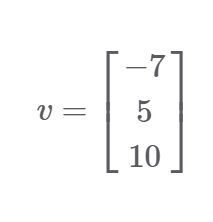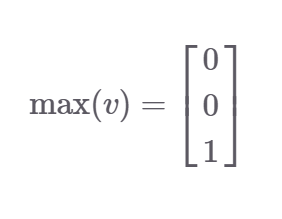

### 소프트맥스 함수의 수식
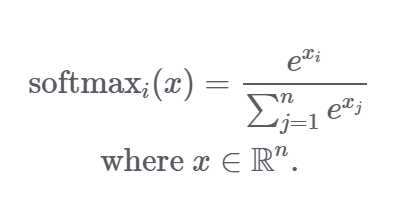
- 소프트맥스 함수의 결과값이 출력 벡터($\hat y$)가 됨
- 이 출력 벡터는 입력 y가 주어졌을 때 입력 샘플이 어떤 클래스에 속할지에 대한 조건부 확률 분포로 볼 수 있음

### 교차 엔트로피 손실 함수
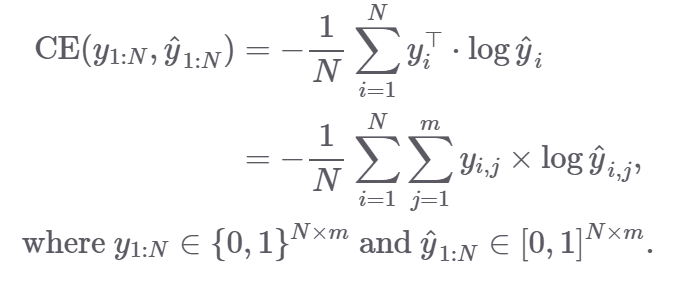
- 위 식에서 $\hat y$는 소프트맥스 함수의 결과값임
- 정답 $y_i$는 원 핫 벡터로 정답 인덱스만 1이고 나머지는 모두 0임
  - 따라서, 모든 출력 차원(j = 0 ~ m) 중에서 한 개의 항만 남게 된다.

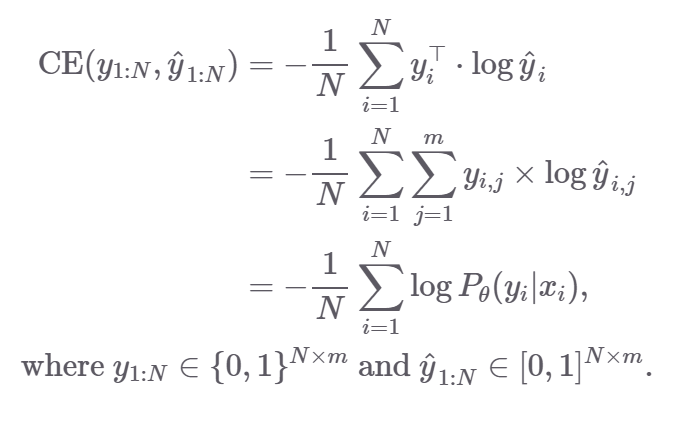
- 예를 들어 다음과 같이 정답 벡터와 모델 출력 벡터가 나왔다면


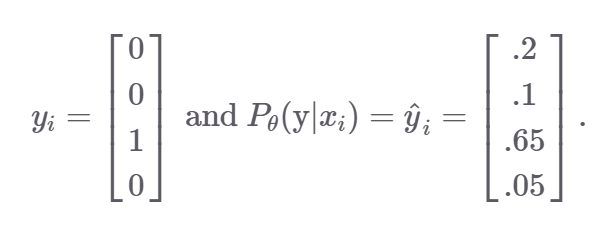

- 두 벡터를 내적하면 다음의 결과를 얻음


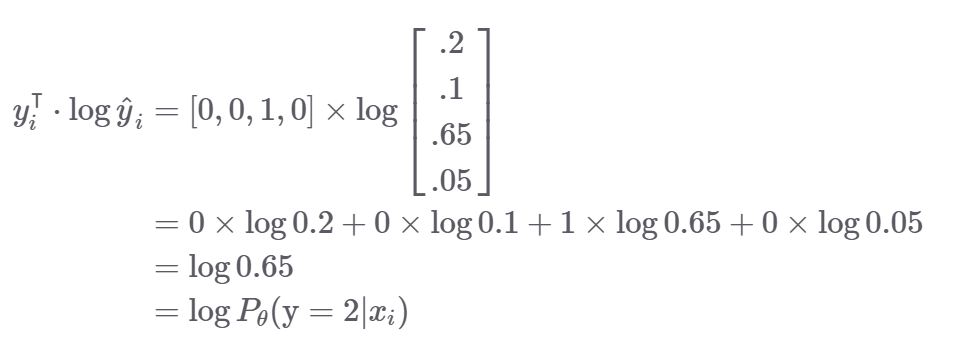

- 파이토치에서는
  - 음의 가능도(NLL: negative log-likeluhood) 손실함수 제공
  - 로그소프트맥스 제공

- 정답을 맞추면 손실이 최소가 되고 정답을 맞추지 못하면 손실이 커짐

### 혼동 행렬
- 분류 문제의 성능 평가 $\to$ 정확도
- 실제 서비스를 위해서는 단순한 정확도보다 잘 틀리는 케이스를 파악하는 것도 중요
- 입력시키는 학습 데이터를 잘 봐야 혼동이 줄어듦
- 다음은 MNIST 분류에 대한 테스트셋 예측 결과를 가지고 혼돈 행렬을 구성한 표<br>
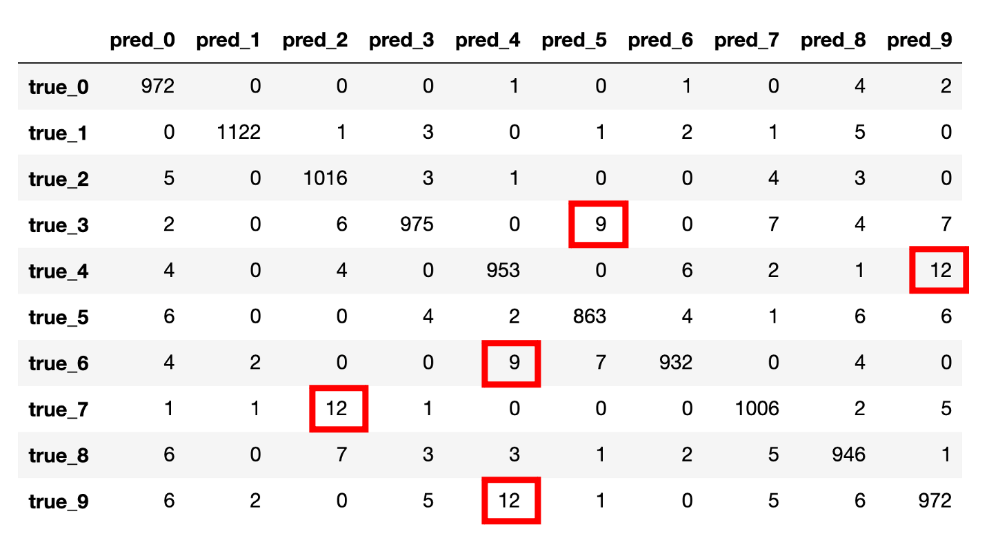
- 가운데 위의 빨간 박스 안의 9는 실제로는 3인데 5로 잘못 예측한 샘플의 개수를 나타냄
- 이 숫자가 큰 것들의 특징을 파악해서 모델을 개선하면 성능을 올릴 수 있음

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

In [11]:
train = datasets.MNIST(
    '../data',train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
)
test = datasets.MNIST(
    '../data', train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
)

In [12]:
def plot(x):
    img = (np.array(x.detach().cpu(), dtype='float')).reshape(28,28)  # CPU로 옮겨야 함
    plt.imshow(img, cmap='gray')
    plt.show()

C:\Users\legna\AppData\Local\Temp\ipykernel_14056\814110150.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = (np.array(x.detach().cpu(), dtype='float')).reshape(28,28)  # CPU로 옮겨야 함


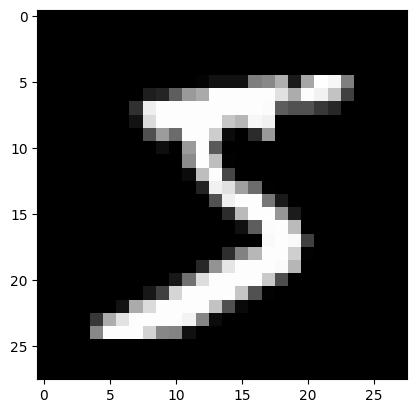

In [13]:
plot(train.data[0])

In [14]:
x = train.data.float() / 255
y = train.targets

x = x.view(x.size(0), -1)
print(x.shape, y.shape)

input_size = x.size(-1)
output_size = int(max(y)) + 1

print('input_size: %d, output_size: %d' % (input_size, output_size))

torch.Size([60000, 784]) torch.Size([60000])
input_size: 784, output_size: 10


In [15]:
ratios = [.8, .2]

train_cnt = int(x.size(0) * ratios[0])
valid_cnt = int(x.size(0) * ratios[1])
test_cnt = len(test.data)
cnts = [train_cnt, valid_cnt]

print("Train %d / Valid %d / Test %d samples." % (train_cnt, valid_cnt, test_cnt))

indices = torch.randperm(x.size(0))

x = torch.index_select(x, dim=0, index=indices)
y = torch.index_select(y, dim=0, index=indices)

x = list(x.split(cnts, dim=0))
y = list(y.split(cnts, dim=0))

x += [(test.data.float() / 255.).view(test_cnt, -1)]
y += [test.targets]

for x_i, y_i in zip(x, y):
    print(x_i.size(), y_i.size())

Train 48000 / Valid 12000 / Test 10000 samples.
torch.Size([48000, 784]) torch.Size([48000])
torch.Size([12000, 784]) torch.Size([12000])
torch.Size([10000, 784]) torch.Size([10000])


In [16]:
n_epochs = 1000
batch_size = 32
print_interval = 10
early_stop = 50

In [17]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 500),
    nn.LeakyReLU(),
    nn.Linear(500, 400),
    nn.LeakyReLU(),
    nn.Linear(400, 300),
    nn.LeakyReLU(),
    nn.Linear(300, 200),
    nn.LeakyReLU(),
    nn.Linear(200, 100),
    nn.LeakyReLU(),
    nn.Linear(100, 50),
    nn.LeakyReLU(),
    nn.Linear(50, y[0].size(-1)),
    nn.LogSoftmax(dim=-1)
)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=500, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=500, out_features=400, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=400, out_features=300, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=300, out_features=200, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=200, out_features=100, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=100, out_features=50, bias=True)
  (11): LeakyReLU(negative_slope=0.01)
  (12): Linear(in_features=50, out_features=48000, bias=True)
  (13): LogSoftmax(dim=-1)
)


In [18]:
crit = nn.NLLLoss()
optimizer = optim.Adam(model.parameters())

In [19]:
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

model = model.to(device)

x = [x_i.to(device) for x_i in x]
y = [y_i.to(device) for y_i in y]

In [20]:
from copy import deepcopy

lowest_loss = np.inf
best_model = None
lowest_epoch = np.inf

train_history, valid_history = [], []

start = time.time()

for i in range(n_epochs):
    # Shuffle
    indices = torch.randperm(x[0].size(0)).to(device)
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0

    for x_i, y_i in zip(x_, y_): # iteraction: 12,384 // 256 + 1 = 49
        y_hat_i = model(x_i)
        loss = crit(y_hat_i, y_i.squeeze())

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        train_loss += float(loss)

    train_loss = train_loss / len(x_) # 1 에폭당 평균 손실값

    with torch.no_grad(): # 계산 그래프 생성을 하지 않음
        #  shuffle 과정 필요 없음
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)

        valid_loss = 0

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = crit(y_hat_i, y_i.squeeze())

            valid_loss += float(loss)
    valid_loss = valid_loss/ len(x_) # 1 epoch 당 평균 손실값

    # 손실곡선을 그리기 위한 손실값 저장
    train_history += [train_loss] # epoch 마다 학습 손실값 차례로 저장
    valid_history += [valid_loss] # epoch 마다 검증 손길값 차례로 저장

    # 출력
    if (i+1) % print_interval == 0:
        print('Epoch %d/%d: train loss = %.4e          valid_loss=%.4e          lowest_loss=%.4e' % (
            i+1,n_epochs, train_loss, valid_loss, lowest_loss))
        start = time.time()
    # 검증 손실의 최소값 찾기
    if valid_loss<=lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i+1:
            print("There is no improvement during last %d epochs." % early_stop)
            break
print("The best validation loss from epoch %d: %.4e" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model)

## 정규화

### 오버피팅
- 학습 오차가 일반화 오차에 비해서 현격하게 낮아지는 현상
- 학습 데이터의 편향이나 노이즈까지 학습 $\to$ 일반화 성능 떨어짐(오차가 커짐)

### 정규화 혼동 표기
- normailization $\to$ 데이터 값을 0~1 사이 값으로 변환
- standardization(정규분호화, 표준화) $\to$ 데이터 분포를 평균 0, 분산 1로 변환
- regularization $\to$ 오버피팅이 발생하지 않도록 가중치 조정(손실함수)을 규체

### 정규화란
- 오버피팅을 늦추고 모델이 학습 데이터로부터 적절한 특징들을 학습하여 일반화 오차를 낮춰줄 수 있는 기법

### 정규화 종류
- 데이터를 통한 정규화
  - 데이터 증강(data augmentation)
- 손실 함수를 통한 정규화
  - 가중치 감쇠(weight decay)
- 신경망 계층을 통한 정규화
  - 드롭아웃(dropout)
  - 배치 정규화(batch normalization)
  - 계층 정규화(layer normalization)
- 학습/추론 방식을 통한 정규화
  - 학습 조기 종료(early stopping)
  - 배깅 & 앙상블(bagging & ensemble)

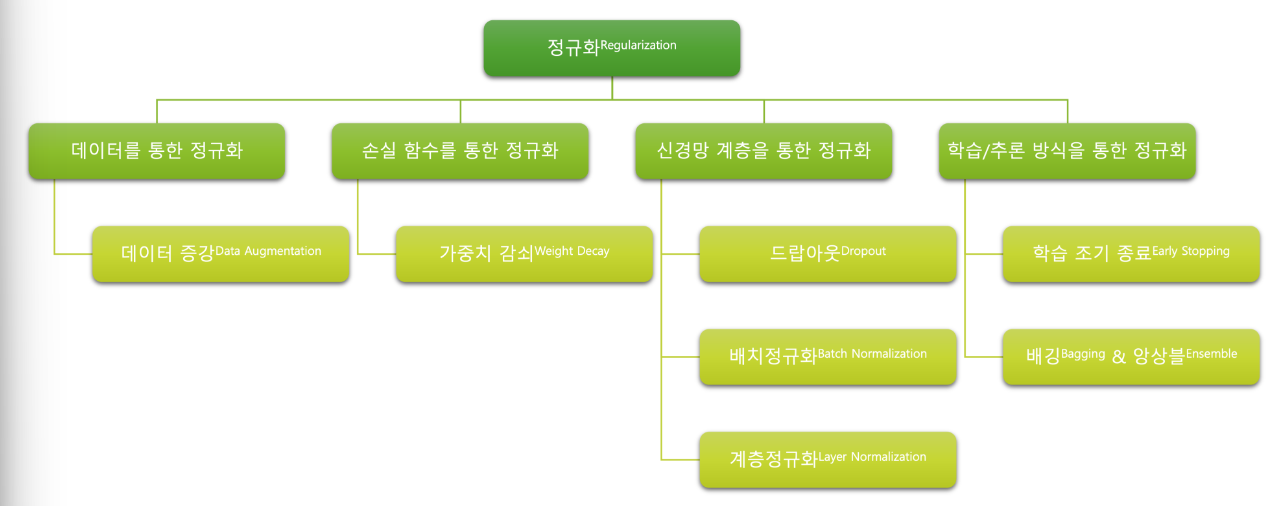